Context
"Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs." [IBM Sample Data Sets]

Content
Each row represents a customer, each column contains customer’s attributes described on the column Metadata.

The data set includes information about:

Customers who left within the last month – the column is called Churn

Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies

Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges

Demographic info about customers – gender, age range, and if they have partners and dependents

### preprocessor.named_transformers_['cat'].categories_

In [1]:
import pandas as pd
import numpy as np
from predict import predict_churn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn import metrics
from sklearn.model_selection import cross_val_score

In [10]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [11]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()
df.info

<bound method DataFrame.info of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL 

In [12]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [13]:
df.isna().sum() #No NA values (WOW)
df.shape #(7043, 21)
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [14]:
df.Churn.value_counts(normalize=True)
# No     0.73463
# Yes    0.26537

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

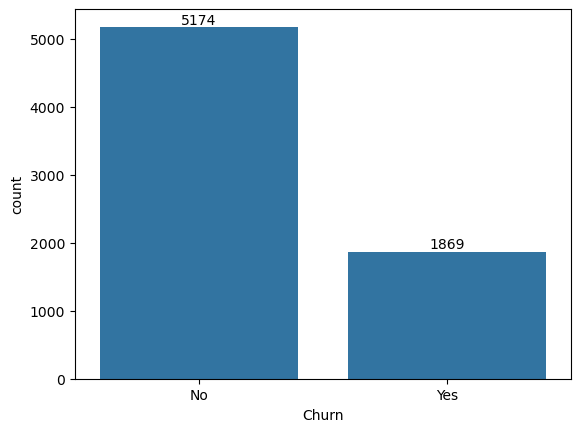

In [15]:
ax = sns.countplot(x='Churn',data= df)
for container in ax.containers:
    ax.bar_label(container)
plt.show()
#It automatically counts how many times each category appears.
#df['Churn'].value_counts()

In [16]:
# Numerical → scaling / distribution
# Categorical → encoding
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print('numerical columns',num_cols);
print('cat_columns',cat_cols);

numerical columns Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')
cat_columns Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')


In [17]:
df.describe

<bound method NDFrame.describe of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DS

In [18]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [19]:
for col in cat_cols:
    print(col, df[col].unique())

customerID ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender ['Female' 'Male']
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
PhoneService ['No' 'Yes']
MultipleLines ['No phone service' 'No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['No' 'Yes' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
TotalCharges ['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']
Churn ['No' 'Yes']


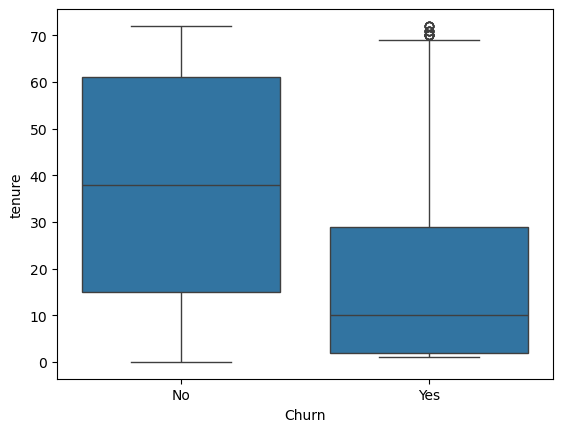

In [20]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.show()

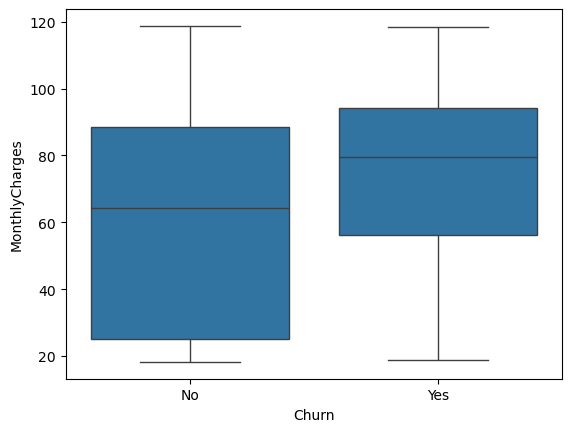

In [21]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

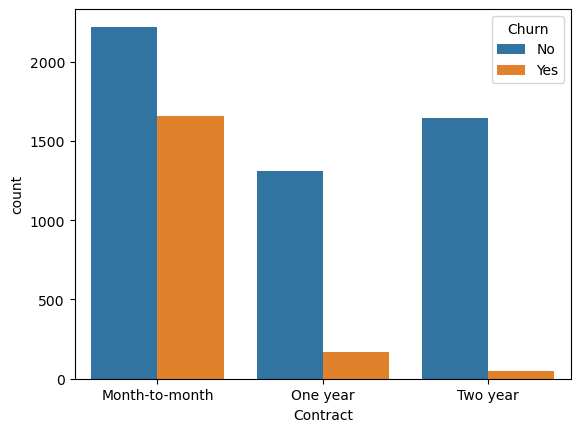

In [22]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.show()

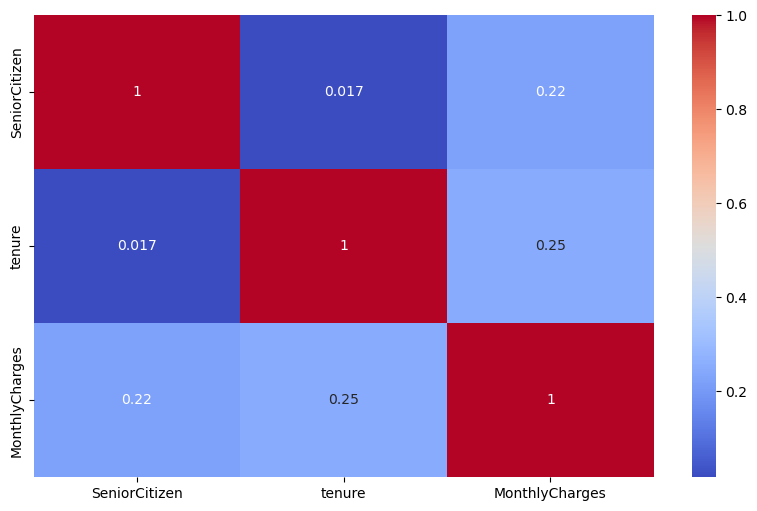

In [23]:
plt.figure(figsize=(10,6))
sns.heatmap(data=df.corr(numeric_only=True),annot = True, cmap='coolwarm')
plt.show()
# tenure and SC does not realte at all.

In [24]:
df["customerID"].nunique() #If every value is unique → useless feature.

7043

In [25]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [26]:
# fig, ax = plt.subplot(layout = 'contraint')
female_yes = df[((df['gender']=='Female') & (df['Churn'] == "Yes"))].shape[0]
female_yes
# rects = ax.bar(height = df['Churn'].value_counts(),label =['Male','Female'])

939

In [27]:
cross = pd.crosstab(df['gender'], df['Churn'],normalize = 'index')
cross

Churn,No,Yes
gender,,
Female,0.730791,0.269209
Male,0.738397,0.261603


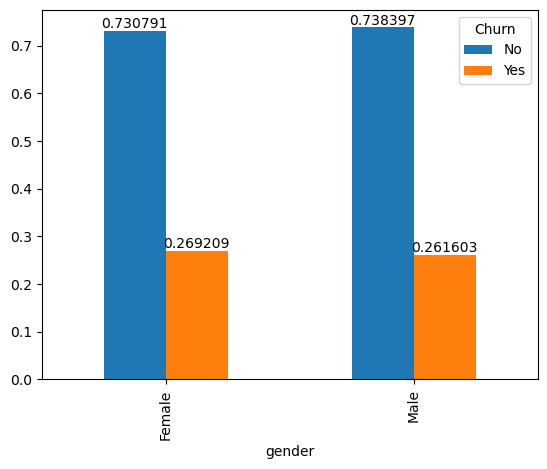

In [28]:
ax= cross.plot(kind= 'bar');
for containers in ax.containers:
    ax.bar_label(containers)
plt.show();

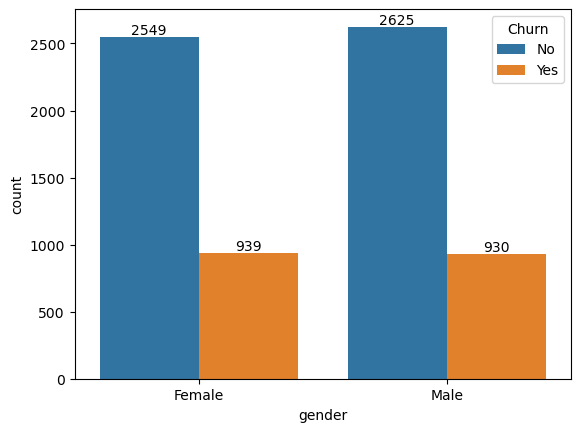

In [29]:
ax = sns.countplot(x='gender',hue = 'Churn',data = df)
for containers in ax.containers:
    ax.bar_label(containers)

<!-- Figure
   └── Axes (ax)
         ├── bars
         ├── labels
         ├── ticks
         ├── legend
         └── containers -->

In [30]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [31]:
cross = pd.crosstab(df['SeniorCitizen'],df['Churn'],normalize= 'index')
cross

Churn,No,Yes
SeniorCitizen,,
0,0.763938,0.236062
1,0.583187,0.416813


(array([0, 1]), [Text(0, 0, 'Not Senior'), Text(1, 0, 'Senior')])

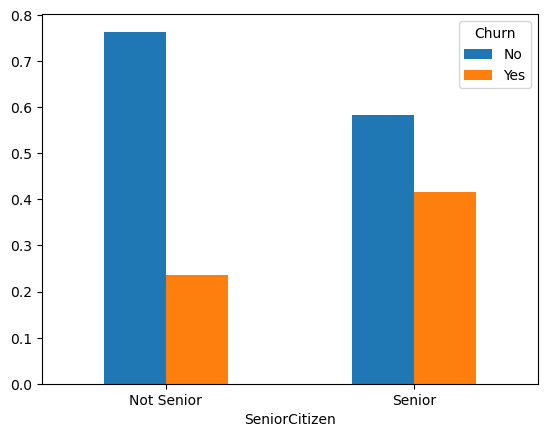

In [32]:
ax = cross.plot(kind = 'bar')
ax.set_xticklabels(['Not Senior', 'Senior'])
plt.xticks(rotation = 0)


In [33]:
cross = pd.crosstab(df['PhoneService'],df['Churn'])
cross

Churn,No,Yes
PhoneService,,
No,512,170
Yes,4662,1699


In [34]:
cross = pd.crosstab(df['MultipleLines'],df['Churn'])
cross

Churn,No,Yes
MultipleLines,,
No,2541,849
No phone service,512,170
Yes,2121,850


In [35]:
cross = pd.crosstab(df['InternetService'],df['Churn'],normalize='index')
cross

Churn,No,Yes
InternetService,,
DSL,0.810409,0.189591
Fiber optic,0.581072,0.418928
No,0.925950,0.074050


'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'

In [36]:
cross = pd.crosstab(df['OnlineSecurity'],df['Churn'],normalize='index')
cross

Churn,No,Yes
OnlineSecurity,,
No,0.582333,0.417667
No internet service,0.925950,0.074050
Yes,0.853888,0.146112


In [37]:
cross = pd.crosstab(df['OnlineBackup'],df['Churn'],normalize='index')
cross

Churn,No,Yes
OnlineBackup,,
No,0.600712,0.399288
No internet service,0.925950,0.074050
Yes,0.784685,0.215315


In [38]:
cross = pd.crosstab(df['DeviceProtection'],df['Churn'],normalize='index')
cross

Churn,No,Yes
DeviceProtection,,
No,0.608724,0.391276
No internet service,0.925950,0.074050
Yes,0.774979,0.225021


In [39]:
cross = pd.crosstab(df['TechSupport'],df['Churn'],normalize='index')
cross

Churn,No,Yes
TechSupport,,
No,0.583645,0.416355
No internet service,0.925950,0.074050
Yes,0.848337,0.151663


In [40]:
cross = pd.crosstab(df['StreamingTV'],df['Churn'],normalize='index')
cross

Churn,No,Yes
StreamingTV,,
No,0.664769,0.335231
No internet service,0.925950,0.074050
Yes,0.699298,0.300702


In [41]:
cross = pd.crosstab(df['StreamingMovies'],df['Churn'],normalize='index')
cross

Churn,No,Yes
StreamingMovies,,
No,0.663196,0.336804
No internet service,0.925950,0.074050
Yes,0.700586,0.299414


In [42]:
cross = pd.crosstab(df['Contract'],df['Churn'],normalize='index')
cross

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


In [43]:
cross = pd.crosstab(df['PaperlessBilling'],df['Churn'],normalize='index')
cross

Churn,No,Yes
PaperlessBilling,,
No,0.836699,0.163301
Yes,0.664349,0.335651


In [44]:
cross = pd.crosstab(df['PaymentMethod'],df['Churn'],normalize='index')
cross

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.832902,0.167098
Credit card (automatic),0.847569,0.152431
Electronic check,0.547146,0.452854
Mailed check,0.808933,0.191067


In [45]:
# Partner	Dependents
cross = pd.crosstab(df['Partner'],df['Churn'],normalize='index')
cross1 = pd.crosstab(df['Dependents'],df['Churn'],normalize='index')
print(cross)
print()
print(cross1)

Churn          No       Yes
Partner                    
No       0.670420  0.329580
Yes      0.803351  0.196649

Churn             No       Yes
Dependents                    
No          0.687209  0.312791
Yes         0.845498  0.154502


# Imp Relationship 

<Axes: xlabel='tenure', ylabel='TotalCharges'>

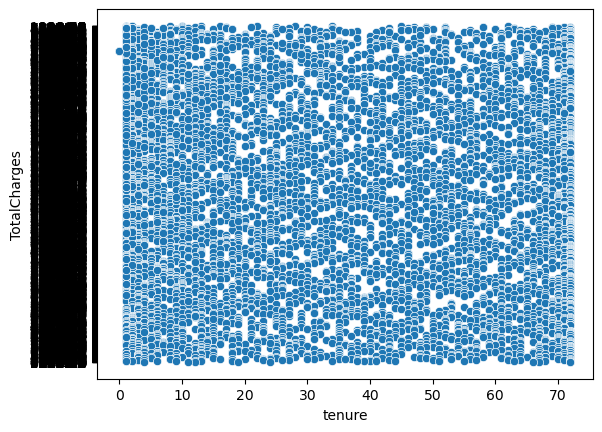

In [46]:
# Imp relationship
sns.scatterplot(x="tenure", y="TotalCharges", data=df)

## Data Cleaning

In [47]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].isna().sum() #11

np.int64(11)

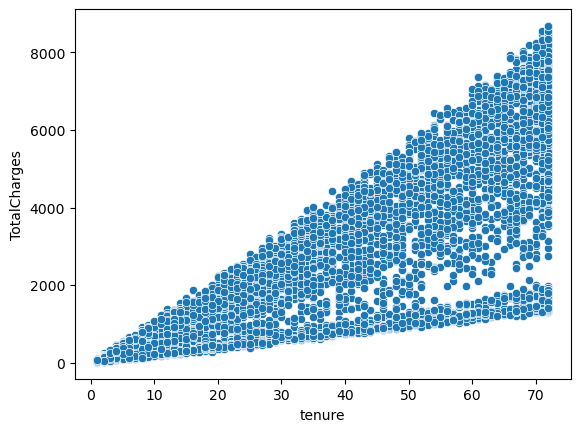

In [48]:
df = df.dropna()
sns.scatterplot(x="tenure", y="TotalCharges", data=df)
plt.show()

In [49]:
df_temp = df.drop('customerID',axis = 1)

## Converting Target Vairables into numeric

In [50]:
df_temp["Churn"] = df_temp["Churn"].map({"Yes": 1, "No": 0})

## Separate Features and Target

In [51]:
X = df_temp.drop("Churn", axis=1)
y = df_temp["Churn"]

## Identify Column Types

In [62]:
nums_dtype = X.select_dtypes(include = ['int64','float64']).columns
cat_dtype = X.select_dtypes(include = ['object','string']).columns
print(nums_dtype)
print(cat_dtype)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


## Encode Categorical Variables

In [63]:
cat_feature = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod']
num_feature = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
cat_transformer = OneHotEncoder(handle_unknown='ignore')
num_transformer = StandardScaler()
preprocessor = ColumnTransformer(transformers=[
                ('cat',cat_transformer,cat_feature),
                ('num',num_transformer, num_feature)
])
models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(),
    "GradientBoost": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(),
    "LightGBM": LGBMClassifier(verbose=-1)
}

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    scores = cross_val_score(pipeline, X, y, cv=5, scoring="roc_auc")
    print(name, scores.mean())

 #Logistic 0.8451284164280946
# RandomForest 0.8192105597143552
# GradientBoost 0.8464887429336448
# XGBoost 0.817507791726403
# LightGBM 0.8350228108774036

Logistic 0.8451284164280946
RandomForest 0.8179148161186902
GradientBoost 0.8465110576323486
XGBoost 0.817507791726403


C:\Users\divya\AI\tel-churn-project\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\divya\AI\tel-churn-project\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\divya\AI\tel-churn-project\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\divya\AI\tel-churn-project\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM 0.8350228108774036


C:\Users\divya\AI\tel-churn-project\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### SInce Gradient is the best, we tune it we have to agaib create seprater pipleine

In [64]:
pipeline_gb = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier())
])

# Train the model

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state  = 42)
pipeline_gb.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [66]:
scores = cross_val_score(pipeline, X, y, cv=5)
print(scores)
print(scores.mean())

C:\Users\divya\AI\tel-churn-project\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\divya\AI\tel-churn-project\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\divya\AI\tel-churn-project\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\divya\AI\tel-churn-project\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[0.80241649 0.80028429 0.78236131 0.79658606 0.79943101]
0.7962158320367276


C:\Users\divya\AI\tel-churn-project\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [67]:
# BY default score = Accuracy which is not good for Churn better use ROC-AOC 
scores = cross_val_score(pipeline, X, y, cv=5,scoring = "roc_auc")
print(scores)
print(scores.mean())

C:\Users\divya\AI\tel-churn-project\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\divya\AI\tel-churn-project\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\divya\AI\tel-churn-project\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\divya\AI\tel-churn-project\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[0.8435583  0.84707202 0.82278768 0.82850133 0.83319472]
0.8350228108774036


C:\Users\divya\AI\tel-churn-project\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


<Axes: >

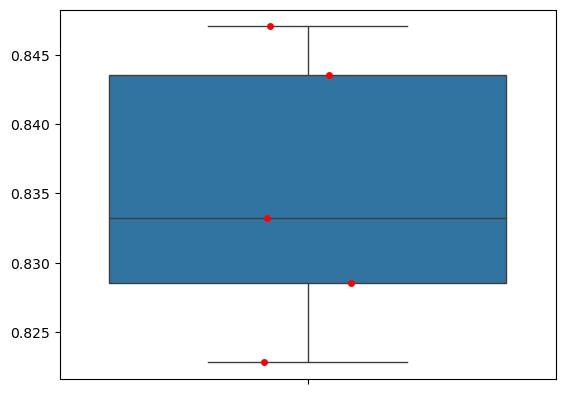

In [68]:
sns.boxplot(y=scores)
sns.stripplot(y=scores, color="red")

# Hyperparamter tuning

Key Hyperparameters for GradientBoost

n_estimators: Number of boosting iterations (trees).

learning_rate: Controls the contribution of each tree.

max_depth: Maximum depth of each tree.

min_samples_split: Minimum number of samples required to split an internal node.

subsample: Fraction of samples used for fitting each tree.

colsample_bytree: Fraction of features used for building each tree.

In [69]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
params_grid = {    "classifier__n_estimators": [100, 200, 300, 400],
    "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "classifier__max_depth": [2, 3, 4, 5],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4] }
random_search = RandomizedSearchCV(estimator=pipeline_gb,
                                  param_distributions=params_grid,
                              scoring = 'roc_auc',
                                  cv = 5,
                              n_jobs =-1,
                              random_state  = 42,
                                   n_iter = 30,
                              verbose = 1)
random_search.fit(X_train,y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__learning_rate': [0.01, 0.05, ...], 'classifier__max_depth': [2, 3, ...], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variou

In [70]:
random_search.best_params_
# {'classifier__n_estimators': 200,
#  'classifier__min_samples_split': 10,
#  'classifier__min_samples_leaf': 1,
#  'classifier__max_depth': 2,
#  'classifier__learning_rate': 0.05}

{'classifier__n_estimators': 200,
 'classifier__min_samples_split': 10,
 'classifier__min_samples_leaf': 1,
 'classifier__max_depth': 2,
 'classifier__learning_rate': 0.05}

In [71]:
random_search.best_score_
#0.8507705264521771

np.float64(0.8507705264521771)

In [72]:

#for LGMB-> random_search.best_params_
# # {'classifier__n_estimators': 200,
# #  'classifier__min_samples_split': 10,
# #  'classifier__min_samples_leaf': 1,
# #  'classifier__max_depth': 2,
# #  'classifier__learning_rate': 0.05}
# random_search.best_score_
#0.8514438766833756

In [73]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__n_estimators": [180, 200, 220],
    "classifier__learning_rate": [0.03, 0.05, 0.07],
    "classifier__max_depth": [2, 3, 4]
}

grid_search = GridSearchCV(
    pipeline_gb,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
grid_search_lgbm = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)
grid_search_lgbm.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...verbose=-1))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__learning_rate': [0.03, 0.05, ...], 'classifier__max_depth': [2, 3, ...], 'classifier__n_estimators': [180, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold 

In [74]:
grid_search.best_params_
# #{'classifier__learning_rate': 0.05,
#  'classifier__max_depth': 2,
#  'classifier__n_estimators': 180}

{'classifier__learning_rate': 0.05,
 'classifier__max_depth': 2,
 'classifier__n_estimators': 180}

In [75]:
grid_search.best_score_
#0.8509579955784821

np.float64(0.8509579955784821)

In [76]:
grid_search_lgbm.best_params_
# {'classifier__learning_rate': 0.03,
#  'classifier__max_depth': 3,
#  'classifier__n_estimators': 220}
grid_search_lgbm.best_score_
#0.8527140508717517

np.float64(0.8527140508717517)

## SInce LGBM gave us better socre we use that

In [77]:
best_model = grid_search_lgbm.best_estimator_
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [78]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]
print(y_pred)
print(y_prob)

[0 0 1 ... 0 0 0]
[0.01247628 0.09007357 0.65925455 ... 0.05609499 0.28689435 0.00409683]


C:\Users\divya\AI\tel-churn-project\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\divya\AI\tel-churn-project\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [79]:
from sklearn.metrics import roc_auc_score

y_prob = best_model.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_prob)
#0.835320777963566

C:\Users\divya\AI\tel-churn-project\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.835320777963566

# Feature Importance

In [80]:
model = best_model.named_steps["classifier"]


importance = pd.Series(
    model.feature_importances_,
    index=best_model.named_steps["preprocessor"].get_feature_names_out()
)

importance.sort_values(ascending=False).head(10)

num__MonthlyCharges                    342
num__tenure                            309
num__TotalCharges                      184
cat__OnlineSecurity_No                  63
cat__Contract_Month-to-month            59
cat__Contract_Two year                  58
cat__PaymentMethod_Electronic check     54
cat__PaperlessBilling_No                50
cat__MultipleLines_No                   46
cat__Contract_One year                  46
dtype: int32

# Save the Final model

In [81]:
import joblib

joblib.dump(best_model, "../models/churn_model.pkl")

['../models/churn_model.pkl']

In [2]:
### Load the model
import joblib

In [3]:
model = joblib.load("../models/churn_model.pkl")

In [5]:
sample = X_test.iloc[[0]]

prediction = best_model.predict(sample)
probability = best_model.predict_proba(sample)[:,1]

print(prediction)
print(probability)

NameError: name 'X_test' is not defined

In [85]:
df_temp['gender'].unique().tolist()

['Female', 'Male']

In [86]:
dic = {}
lst = [
"gender",
"SeniorCitizen",
"Partner",
"tenure",
"MonthlyCharges",

]
for col in df_temp.columns:
    if col in lst:
        continue
    else:
        dic[col] = df_temp[col].unique().tolist()
print(dic)

{'Dependents': ['No', 'Yes'], 'PhoneService': ['No', 'Yes'], 'MultipleLines': ['No phone service', 'No', 'Yes'], 'InternetService': ['DSL', 'Fiber optic', 'No'], 'OnlineSecurity': ['No', 'Yes', 'No internet service'], 'OnlineBackup': ['Yes', 'No', 'No internet service'], 'DeviceProtection': ['No', 'Yes', 'No internet service'], 'TechSupport': ['No', 'Yes', 'No internet service'], 'StreamingTV': ['No', 'Yes', 'No internet service'], 'StreamingMovies': ['No', 'Yes', 'No internet service'], 'Contract': ['Month-to-month', 'One year', 'Two year'], 'PaperlessBilling': ['Yes', 'No'], 'PaymentMethod': ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)'], 'TotalCharges': [29.85, 1889.5, 108.15, 1840.75, 151.65, 820.5, 1949.4, 301.9, 3046.05, 3487.95, 587.45, 326.8, 5681.1, 5036.3, 2686.05, 7895.15, 1022.95, 7382.25, 528.35, 1862.9, 39.65, 202.25, 20.15, 3505.1, 2970.3, 1530.6, 4749.15, 30.2, 6369.45, 1093.1, 6766.95, 181.65, 1874.45, 20.2, 45.25, 7251.7, 

In [5]:
sample = ['Male', 0, 'Yes', 'No', 12, 'Yes', 'No', 'Fiber optic', 'No', 'Yes', 'No', 'No', 'Yes', 'No', 'Month-to-month', 'Yes', 'Electronic check', 70.5, 845.0]

print(predict_churn(sample))

C:\Users\divya\AI\tel-churn-project\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


1


In [7]:
model.dtypes()

AttributeError: 'Pipeline' object has no attribute 'dtypes'